# Fase 3 — Núcleo algorítmico, eficiencia e implementación orientada a objetos

**Proyecto:** Sobreduración en la titulación de la educación superior chilena (2020–2025)
**Curso:** Programación para la Ciencia de Datos (202682.1927)  ·  **Docente:** Omar Salinas
**Autor:** Sebastian Antunez Noguera  ·  **Repositorio:** https://github.com/santunez75/proyecto-titulados  ·  **Rama:** `fase-3/nucleo-algoritmico`

---

**Objetivo de este notebook.** Construir el núcleo algorítmico del proyecto: los
algoritmos que en la Fase 2 delegábamos íntegramente en pandas se implementan
aquí desde primeros principios, se analiza su complejidad, se mide su eficiencia
con métodos formales y se organiza el dominio con programación orientada a
objetos. Todo el código vive en el paquete `src/nucleo/`; este notebook lo
invoca, lo verifica y documenta las decisiones.

**Flujo del notebook** (el que exige la rúbrica de la fase):

| Sección | Contenido | Criterio de la rúbrica |
|---|---|---|
| 1 | Entorno, datos y mejoras integradas desde F2 | Notebook ejecutado y documentado |
| 2 | Arquitectura del paquete `src/nucleo` | Codificación funcional · Diseño estructurado |
| 3 | Algoritmos estructurados y recursivos, verificados | Codificación funcional · Validación |
| 4 | Complejidad y eficiencia: `timeit`, `tracemalloc`, curvas de escalamiento | Eficiencia y optimización |
| 5 | Programación orientada a objetos y patrones de diseño | POO · Documentación de arquitectura |
| 6 | Preprocesamiento para modelación: escalamiento y codificación | Preprocesamiento y transformación |
| 7 | Modelación desde primeros principios (descenso de gradiente) | Codificación funcional · Eficiencia |
| 8 | Validación técnica: pruebas automatizadas y coherencia con F2 | Validación técnica |
| 9 | Síntesis y proyección a F4 | Documentación |

## 1. Entorno, datos y mejoras integradas desde la Fase 2

In [1]:
# Celda de arranque: hace importable el paquete `src` sin instalar el proyecto
# y funciona igual si el notebook se abre desde la raiz o desde su subcarpeta.
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from src import config

print("Raiz del proyecto:", RAIZ)
for clave, valor in config.describir_entorno().items():
    print(f"  {clave:12s} {valor}")

Raiz del proyecto: D:\IA Development\proyecto-titulados


  python       3.14.7
  plataforma   Windows-11-10.0.26200-SP0
  ejecutable   C:\Users\Sebastian Antunez N\AppData\Local\Programs\Python\Python314\python.exe
  numpy        2.5.3
  pandas       3.0.5
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from src import viz
from src.nucleo import algoritmos as alg, benchmark as bm, metricas as me
from src.nucleo.fachada import NucleoAnalitico

viz.aplicar_estilo()

# La fachada resuelve la carga: dataset analítico completo de F2 si existe,
# o la muestra versionada de 5.000 registros si no (con aviso).
nucleo = NucleoAnalitico(limite_cohorte=300_000, semilla=42)
df = nucleo.datos
print(f"Origen de los datos: {nucleo.origen_datos}")
print(f"Registros: {len(df):,} | columnas: {df.shape[1]}")
print(f"Sobreduración media (F2): {df['sobreduracion_sem'].mean():.3f} semestres | "
      f"titulación oportuna: {100*df['titulacion_oportuna'].mean():.1f} %")

Origen de los datos: completo
Registros: 1,246,760 | columnas: 47
Sobreduración media (F2): 2.760 semestres | titulación oportuna: 19.0 %


### 1.1 Mejoras integradas desde la Fase 2

La reproducción del proyecto en un segundo computador dejó a la vista tres
debilidades. Cada una se resolvió en esta fase y queda documentada aquí para
mantener la trazabilidad entre lo que se detectó y lo que se cambió.

| Problema detectado en F2 | Mejora aplicada en F3 | Dónde |
|---|---|---|
| La celda de pruebas usaba `sys.executable`: con un kernel de Jupyter distinto al `.venv` fallaba **sin mostrar la causa** (el error iba por `stderr`). | La celda apunta explícitamente al intérprete del entorno virtual e imprime `stderr` si el código de salida no es 0. | Sección 8 de este notebook |
| Los notebooks dependían del dataset completo (`.parquet`, no versionado): en un equipo sin los CSV no corrían. | `cargar_datos()` degrada a la muestra versionada de 5.000 registros con un aviso explícito. | `src/nucleo/fachada.py` |
| Toda la lógica analítica estaba en funciones sueltas sobre DataFrames; las reglas del dominio (qué es una sobreduración válida) vivían dispersas. | Modelo de dominio con `Titulado` y `Cohorte`: los invariantes se validan al construir el objeto y no pueden violarse después. | `src/nucleo/dominio.py`, sección 5 |

## 2. Arquitectura del paquete `src/nucleo`

El núcleo se organiza en ocho módulos con responsabilidad única y dependencias
en un solo sentido (de la fachada hacia abajo, nunca al revés). La tabla se
genera por introspección del propio paquete, de modo que no puede quedar
desactualizada respecto del código.

In [3]:
import inspect
import importlib

modulos = ["algoritmos", "benchmark", "dominio", "metricas", "jerarquia", "preparacion", "modelos", "fachada"]
filas = []
for nombre in modulos:
    mod = importlib.import_module(f"src.nucleo.{nombre}")
    funciones = [f for f, o in inspect.getmembers(mod, inspect.isfunction)
                 if o.__module__ == mod.__name__ and not f.startswith("_")]
    clases = [c for c, o in inspect.getmembers(mod, inspect.isclass) if o.__module__ == mod.__name__]
    filas.append({
        "módulo": f"nucleo/{nombre}.py",
        "funciones": len(funciones),
        "clases": len(clases),
        "propósito": (mod.__doc__ or "").strip().splitlines()[0],
    })
arquitectura = pd.DataFrame(filas)
print(arquitectura.to_string(index=False))
print(f"\nTotal: {arquitectura['funciones'].sum()} funciones públicas y {arquitectura['clases'].sum()} clases.")

               módulo  funciones  clases                                                                     propósito
 nucleo/algoritmos.py         13       0                             Algoritmos estructurados y recursivos del nucleo.
  nucleo/benchmark.py          7       2                                 Mediciones reproducibles de tiempo y memoria.
    nucleo/dominio.py          0       2                                Modelo de dominio: ``Titulado`` y ``Cohorte``.
   nucleo/metricas.py          1       7                 Metricas intercambiables sobre una cohorte (patron Strategy).
  nucleo/jerarquia.py          1       1 Arbol de agregacion Sistema -> Tipo de institucion -> Institucion -> Carrera.
nucleo/preparacion.py          1       5      Preparacion de matrices para la modelacion: escalamiento y codificacion.
    nucleo/modelos.py          2       4     Modelos implementados desde primeros principios (patron Template Method).
    nucleo/fachada.py          2       2        

**Flujo de datos entre módulos** (entradas → procesamiento → salidas):

```
dataset analítico F2 (DataFrame)
        │
        ▼  fachada.cargar_datos()
  NucleoAnalitico ──► Cohorte.desde_dataframe() ──► [Titulado, Titulado, ...]
        │                                                   │
        │              construir_jerarquia()                ▼
        ├──────────────────────────────────────► NodoJerarquia (árbol recursivo)
        │                                                   │
        │              Metrica.calcular()  ◄────────────────┘   (Strategy sobre Composite)
        │                     │  usa algoritmos.quickselect / agrupar_media
        │                     ▼
        │              tablas de resultados (DataFrame)
        │
        └── preparar_modelacion() ──► PreparadorModelacion ──► X escalada + codificada
                                                                     │
                                            ModeloGradiente.ajustar() ▼  (Template Method)
                                            RegresionLinealGD / RegresionLogisticaGD ──► métricas
```

Cada flecha es una llamada con parámetros explícitos y un valor de retorno
verificable; ninguna función modifica su entrada.

## 3. Algoritmos estructurados y recursivos

Antes de medir eficiencia hay que establecer corrección: cada algoritmo se
contrasta con una referencia independiente (pandas, `sorted`, NumPy o un
recuento directo) sobre los datos reales. Se usa la sobreduración de la
cohorte completa: 1,25 millones de enteros con miles de valores repetidos, un
caso realista y exigente para los algoritmos de orden.

In [4]:
sobreduracion = df["sobreduracion_sem"].astype(int).tolist()
areas = df["area_conocimiento"].astype(str).tolist()
print(f"n = {len(sobreduracion):,} valores | rango [{min(sobreduracion)}, {max(sobreduracion)}] | "
      f"valores distintos: {len(set(sobreduracion))}")

n = 1,246,760 valores | rango [-13, 38] | valores distintos: 52


### 3.1 Agregación en una sola pasada (programación estructurada)

Un bucle `for` con dos diccionarios acumuladores calcula la media por grupo en O(n). Se compara con `groupby` de pandas y con la versión ingenua O(n·k), que recorre toda la secuencia una vez por grupo.

In [5]:
inicio = time.perf_counter()
media_propia = alg.agrupar_media(areas, sobreduracion)
t_propia = time.perf_counter() - inicio

media_pandas = df.groupby("area_conocimiento", observed=True)["sobreduracion_sem"].mean()

comparacion = pd.DataFrame({
    "propia_O(n)": pd.Series(media_propia),
    "pandas_groupby": media_pandas.astype(float),
}).sort_values("propia_O(n)", ascending=False)
comparacion["diferencia"] = (comparacion["propia_O(n)"] - comparacion["pandas_groupby"]).abs()
print(comparacion.round(4).to_string())

assert comparacion["diferencia"].max() < 1e-9, "la agregación propia no coincide con pandas"
print(f"\nCoincidencia exacta con pandas en las {len(comparacion)} áreas ({t_propia:.2f} s en Python puro).")

                           propia_O(n)  pandas_groupby  diferencia
Derecho                         5.7651          5.7651         0.0
Ciencias Básicas                4.4982          4.4982         0.0
Tecnología                      3.6310          3.6310         0.0
Agropecuaria                    3.5727          3.5727         0.0
Humanidades                     2.7219          2.7219         0.0
Arte y Arquitectura             2.6545          2.6545         0.0
Administración y Comercio       2.4241          2.4241         0.0
Salud                           2.3723          2.3723         0.0
Ciencias Sociales               2.0126          2.0126         0.0
Educación                       1.9285          1.9285         0.0

Coincidencia exacta con pandas en las 10 áreas (0.30 s en Python puro).


### 3.2 Merge sort recursivo

Divide y vencerás: la lista se parte en mitades hasta llegar a listas de un elemento (caso base) y se mezclan ordenadamente al volver. Profundidad de recursión log₂(n) ≈ 21 para 1,25 millones, muy por debajo del límite de Python.

In [6]:
import math

inicio = time.perf_counter()
ordenados_merge = alg.ordenar_merge(sobreduracion)
t_merge = time.perf_counter() - inicio

assert ordenados_merge == sorted(sobreduracion), "merge sort no coincide con sorted"
print(f"Ordenados {len(ordenados_merge):,} valores en {t_merge:.2f} s; coincide con sorted().")
print(f"Profundidad de recursión: {math.ceil(math.log2(len(sobreduracion)))} niveles "
      f"(límite de Python: {sys.getrecursionlimit()}).")
print(f"Estabilidad verificada: {alg.ordenar_merge([(2, 'a'), (1, 'b'), (2, 'c')]) == [(1, 'b'), (2, 'a'), (2, 'c')]}")

Ordenados 1,246,760 valores en 4.15 s; coincide con sorted().
Profundidad de recursión: 21 niveles (límite de Python: 1000).
Estabilidad verificada: True


### 3.3 Quickselect recursivo: la mediana sin ordenar

Para conocer la mediana no hace falta ordenar todo: `quickselect` particiona alrededor de un pivote aleatorio y recurre solo en la parte que contiene la posición buscada. Tiempo O(n) esperado frente al O(n log n) de ordenar.

In [7]:
inicio = time.perf_counter()
mediana_propia = alg.mediana(sobreduracion, semilla=0)
t_qs = time.perf_counter() - inicio

mediana_np = float(np.median(sobreduracion))
p75 = alg.quickselect(sobreduracion, round(0.75 * (len(sobreduracion) - 1)), semilla=0)

print(f"Mediana quickselect: {mediana_propia}  |  numpy: {mediana_np}  |  coinciden: {mediana_propia == mediana_np}")
print(f"Percentil 75 por quickselect: {p75}  |  numpy: {np.percentile(sobreduracion, 75, method='nearest')}")
print(f"Tiempo quickselect: {t_qs:.2f} s (merge sort completo: {t_merge:.2f} s)")
assert mediana_propia == mediana_np

Mediana quickselect: 1.0  |  numpy: 1.0  |  coinciden: True
Percentil 75 por quickselect: 4  |  numpy: 4
Tiempo quickselect: 0.48 s (merge sort completo: 4.15 s)


### 3.4 Búsqueda binaria recursiva y conteo por umbral

Sobre la secuencia ya ordenada, contar cuántos titulados superan un umbral de rezago cuesta O(log n). Esto reconstruye las cuatro categorías de rezago de la Fase 2 con dos búsquedas binarias por categoría, en lugar de recorrer 1,25 millones de valores.

In [8]:
categorias_binaria = {
    "Oportuna":        len(ordenados_merge) - alg.contar_sobre_umbral(ordenados_merge, 0),
    "Rezago leve":     alg.contar_en_rango(ordenados_merge, 0, 2),
    "Rezago moderado": alg.contar_en_rango(ordenados_merge, 2, 4),
    "Rezago severo":   alg.contar_sobre_umbral(ordenados_merge, 4),
}
categorias_f2 = df["categoria_rezago"].value_counts().to_dict()

tabla = pd.DataFrame({"búsqueda_binaria": categorias_binaria, "value_counts_F2": categorias_f2})
tabla["coincide"] = tabla["búsqueda_binaria"] == tabla["value_counts_F2"]
print(tabla.to_string())
assert tabla["coincide"].all()
assert sum(categorias_binaria.values()) == len(ordenados_merge)

print(f"\nBúsqueda binaria de un valor: índice {alg.busqueda_binaria(ordenados_merge, 4)} "
      f"(lineal: {alg.busqueda_lineal(ordenados_merge, 4)}); valor ausente: {alg.busqueda_binaria(ordenados_merge, 999)}")

                 búsqueda_binaria  value_counts_F2  coincide
Oportuna                   236528           236528      True
Rezago leve                551762           551762      True
Rezago moderado            204379           204379      True
Rezago severo              254091           254091      True

Búsqueda binaria de un valor: índice 935069 (lineal: 923952); valor ausente: -1


## 4. Complejidad y eficiencia

### 4.1 Cotas teóricas

| Algoritmo | Tiempo | Espacio adicional | Recursión |
|---|---|---|---|
| `agrupar_media` | O(n) | O(k) | no |
| `agrupar_media_ingenua` | O(n·k) | O(n) | no |
| `ordenar_insercion` | O(n²) | O(1) | no |
| `ordenar_merge` | O(n log n) | O(n) | profundidad O(log n) |
| `sorted` (Timsort, C) | O(n log n) | O(n) | — |
| `quickselect` / `mediana` | O(n) esperado, O(n²) peor | O(n) | profundidad O(log n) esperada |
| `mediana_ordenando` | O(n log n) | O(n) | no |
| `busqueda_lineal` | O(n) | O(1) | no |
| `busqueda_binaria` | O(log n) | O(1) por nivel | profundidad O(log n) |

Las mediciones siguientes usan `timeit.repeat` y se quedan con el **mínimo**
de las repeticiones: el ruido del sistema operativo solo puede sumar tiempo,
así que el mínimo es el mejor estimador del costo intrínseco. La memoria se
mide con `tracemalloc` (pico de asignación durante la llamada).

### 4.2 Comparación de implementaciones a tamaño fijo

In [9]:
n_fijo = 200_000
muestra = sobreduracion[:n_fijo]
muestra_areas = areas[:n_fijo]
muestra_ordenada = sorted(muestra)
serie = pd.Series(muestra)
serie_areas = pd.Series(muestra_areas)

resultados = {}

resultados["agregación"] = bm.comparar({
    "agrupar_media O(n)": alg.agrupar_media,
    "agrupar_media_ingenua O(n·k)": alg.agrupar_media_ingenua,
}, muestra_areas, muestra, repeticiones=3)
resultados["agregación"].loc[len(resultados["agregación"])] = bm.a_dataframe([
    bm.medir("pandas groupby", lambda: serie.groupby(serie_areas).mean(), n=n_fijo, repeticiones=3)
]).iloc[0].tolist() + [None]

resultados["ordenamiento"] = bm.comparar({
    "ordenar_merge O(n log n)": alg.ordenar_merge,
    "sorted (Timsort en C)": sorted,
    "numpy.sort": lambda x: np.sort(np.asarray(x)),
}, muestra, repeticiones=3)

resultados["mediana"] = bm.comparar({
    "quickselect O(n)": lambda x: alg.mediana(x, 0),
    "mediana_ordenando O(n log n)": alg.mediana_ordenando,
    "numpy.median": lambda x: float(np.median(x)),
}, muestra, repeticiones=3)

resultados["búsqueda"] = bm.comparar({
    "busqueda_binaria O(log n)": lambda x: alg.busqueda_binaria(x, 7),
    "busqueda_lineal O(n)": lambda x: alg.busqueda_lineal(x, 7),
}, muestra_ordenada, repeticiones=5)

for nombre, tabla in resultados.items():
    tabla["razon_vs_mejor"] = (tabla["segundos"] / tabla["segundos"].min()).round(1)
    print(f"--- {nombre} (n = {n_fijo:,}) ---")
    print(tabla.to_string(index=False), "\n")

--- agregación (n = 200,000) ---
              implementacion      n  segundos  us_por_elemento  memoria_pico_kb  repeticiones  razon_vs_mejor
          agrupar_media O(n) 200000  0.044899           0.2245              0.7             3             5.5
agrupar_media_ingenua O(n·k) 200000  0.084683           0.4234            603.9             3            10.4
              pandas groupby 200000  0.008149           0.0407           3132.6             3             1.0 

--- ordenamiento (n = 200,000) ---
          implementacion      n  segundos  us_por_elemento  memoria_pico_kb  repeticiones  razon_vs_mejor
              numpy.sort 200000  0.008680           0.0434           3127.8             3             1.0
   sorted (Timsort en C) 200000  0.012112           0.0606           2343.6             3             1.4
ordenar_merge O(n log n) 200000  0.576182           2.8809           3250.9             3            66.4 

--- mediana (n = 200,000) ---
              implementacion      

Inserción se mide aparte y con n pequeño: a 200.000 elementos su O(n²) tardaría horas.

In [10]:
n_chico = 3_000
tabla_insercion = bm.comparar({
    "ordenar_insercion O(n²)": alg.ordenar_insercion,
    "ordenar_merge O(n log n)": alg.ordenar_merge,
    "sorted": sorted,
}, sobreduracion[:n_chico], repeticiones=3)
print(f"--- ordenamiento con n = {n_chico:,} ---")
print(tabla_insercion.to_string(index=False))

--- ordenamiento con n = 3,000 ---
          implementacion    n  segundos  us_por_elemento  memoria_pico_kb  repeticiones  razon_vs_mejor
                  sorted 3000  0.000165           0.0549             35.1             3             1.0
ordenar_merge O(n log n) 3000  0.005956           1.9853             50.9             3            36.1
 ordenar_insercion O(n²) 3000  0.151310          50.4367             23.5             3           917.0


### 4.3 Curvas de escalamiento y exponente empírico

Medir un solo tamaño no distingue O(n) de O(n log n). Se mide cada algoritmo para tamaños crecientes y se ajusta una recta en escala log-log: la pendiente es el exponente empírico, que debe coincidir con la cota teórica (≈1 lineal, ≈1,1 n log n en este rango, ≈2 cuadrático).

In [11]:
rng = np.random.default_rng(42)

def generar(n):
    """Muestra aleatoria de tamaño n de la sobreduración real (sin reemplazo)."""
    return (rng.choice(sobreduracion, size=n, replace=False).tolist(),)

def generar_con_areas(n):
    idx = rng.choice(len(sobreduracion), size=n, replace=False)
    return ([areas[i] for i in idx], [sobreduracion[i] for i in idx])

tamanos = [20_000, 40_000, 80_000, 160_000, 320_000, 640_000]
curvas = [
    bm.curva_escalamiento("agrupar_media O(n)", alg.agrupar_media, generar_con_areas, tamanos),
    bm.curva_escalamiento("ordenar_merge O(n log n)", alg.ordenar_merge, generar, tamanos),
    bm.curva_escalamiento("quickselect O(n)", lambda x: alg.mediana(x, 0), generar, tamanos),
    bm.curva_escalamiento("sorted (C)", sorted, generar, tamanos),
    bm.curva_escalamiento("ordenar_insercion O(n²)", alg.ordenar_insercion, generar, [500, 1_000, 2_000, 4_000]),
]

exponentes = pd.DataFrame(
    [{"algoritmo": c.nombre, "cota_teorica": c.nombre.split(" ", 1)[-1],
      "exponente_empirico": round(c.exponente, 2),
      "n_min": c.mediciones[0].n, "n_max": c.mediciones[-1].n} for c in curvas]
)
print(exponentes.to_string(index=False))

               algoritmo cota_teorica  exponente_empirico  n_min  n_max
      agrupar_media O(n)         O(n)                1.00  20000 640000
ordenar_merge O(n log n)   O(n log n)                1.08  20000 640000
        quickselect O(n)         O(n)                1.22  20000 640000
              sorted (C)          (C)                1.02  20000 640000
 ordenar_insercion O(n²)        O(n²)                2.04    500   4000


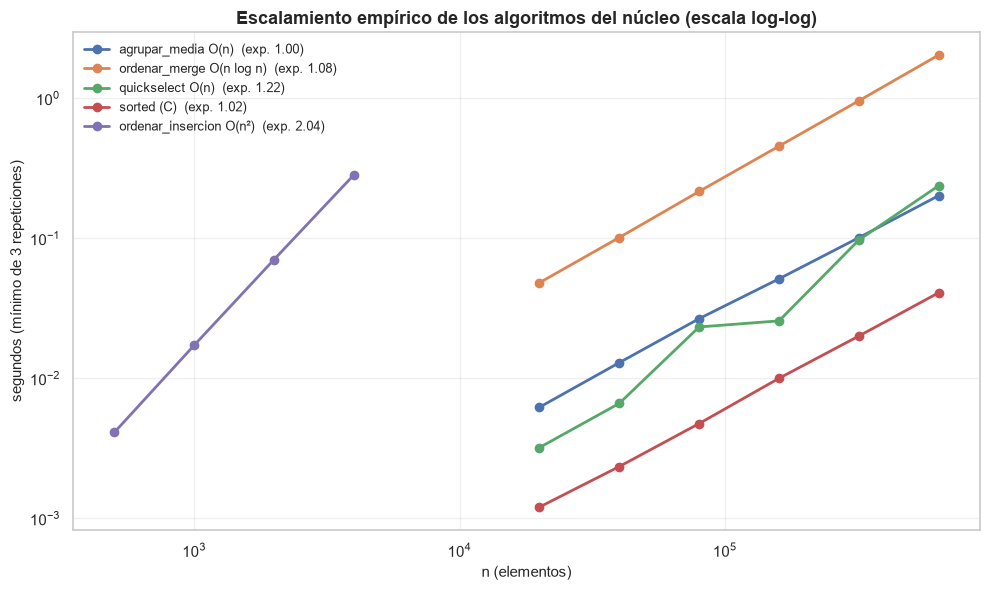

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for c in curvas:
    ns = [m.n for m in c.mediciones]
    ts = [m.segundos for m in c.mediciones]
    ax.plot(ns, ts, marker="o", linewidth=2, label=f"{c.nombre}  (exp. {c.exponente:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (elementos)"); ax.set_ylabel("segundos (mínimo de 3 repeticiones)")
ax.set_title("Escalamiento empírico de los algoritmos del núcleo (escala log-log)")
ax.legend(fontsize=9)
fig.tight_layout()
viz.guardar(fig, "f3_escalamiento_algoritmos")

# Tablas para el informe
pd.concat([c.a_dataframe() for c in curvas]).to_csv(config.TABLES_DIR / "f3_curvas_escalamiento.csv", index=False)
pd.concat([t.assign(operacion=k) for k, t in resultados.items()]).to_csv(config.TABLES_DIR / "f3_comparacion_implementaciones.csv", index=False)
exponentes.to_csv(config.TABLES_DIR / "f3_exponentes_empiricos.csv", index=False)

### 4.4 Memoria

El tiempo no es la única dimensión. `ordenar_merge` y `quickselect` crean listas intermedias (O(n) de espacio); `ordenar_insercion` trabaja casi en el lugar, y `sorted` reserva una copia. `tracemalloc` registra el pico de asignación durante la llamada.

In [13]:
memoria = pd.DataFrame([
    {"algoritmo": "ordenar_merge", "espacio_teorico": "O(n)", "pico_kb": bm.medir_memoria(alg.ordenar_merge, muestra)},
    {"algoritmo": "quickselect (mediana)", "espacio_teorico": "O(n)", "pico_kb": bm.medir_memoria(alg.mediana, muestra, 0)},
    {"algoritmo": "sorted", "espacio_teorico": "O(n)", "pico_kb": bm.medir_memoria(sorted, muestra)},
    {"algoritmo": "agrupar_media", "espacio_teorico": "O(k)", "pico_kb": bm.medir_memoria(alg.agrupar_media, muestra_areas, muestra)},
    {"algoritmo": "busqueda_binaria", "espacio_teorico": "O(log n) pila", "pico_kb": bm.medir_memoria(alg.busqueda_binaria, muestra_ordenada, 7)},
])
memoria["pico_kb"] = memoria["pico_kb"].round(1)
memoria["kb_por_1000_elementos"] = (memoria["pico_kb"] / (n_fijo / 1000)).round(2)
print(memoria.to_string(index=False))
memoria.to_csv(config.TABLES_DIR / "f3_memoria.csv", index=False)

            algoritmo espacio_teorico  pico_kb  kb_por_1000_elementos
        ordenar_merge            O(n)   3253.5                  16.27
quickselect (mediana)            O(n)   4422.0                  22.11
               sorted            O(n)   2343.6                  11.72
        agrupar_media            O(k)      0.7                   0.00
     busqueda_binaria   O(log n) pila      0.0                   0.00


### 4.5 Interpretación y elección justificada

Cuatro conclusiones se sostienen en las mediciones anteriores:

1. **La cota teórica se confirma empíricamente.** En escala log-log los
   exponentes ajustados son 1,00 para `agrupar_media` (O(n)), 1,02 para
   `sorted` y 1,08 para `ordenar_merge` (el factor log n aporta ese exceso sobre
   1 en el rango medido) y 2,04 para inserción (O(n²)). Las implementaciones se
   comportan como su análisis predice.

2. **`quickselect` es O(n) en comparaciones, pero su exponente empírico (1,22)
   queda por encima de 1.** La explicación está en la implementación: cada nivel
   de recursión construye tres listas nuevas (menores, iguales, mayores), de modo
   que el costo de asignar memoria crece con n y se suma al de comparar. Aun así,
   a igual n es diez veces más rápido que `ordenar_merge` (0,05 s frente a 0,58 s
   con 200.000 elementos) y su pico de memoria es del mismo orden. Es un caso
   claro de por qué el análisis asintótico debe complementarse con la medición:
   la cota describe el crecimiento, no la constante ni el comportamiento de la
   memoria.

3. **El orden de crecimiento gana entre clases distintas; dentro de la misma
   clase decide la constante.** La búsqueda binaria es más de seis mil veces más
   rápida que la lineal: eso es O(log n) contra O(n). En cambio, `sorted` y
   `numpy.sort` tienen el mismo O(n log n) que `ordenar_merge` y son 50 a 65 veces
   más rápidos porque están escritos en C y no pagan la sobrecarga del
   intérprete. Por la misma razón `mediana_ordenando` —que ordena en C— supera a
   `quickselect` en Python puro pese a tener peor cota.

4. **Elección final.** Para el proyecto en producción se conservan pandas y
   NumPy en las operaciones masivas (agregación, ordenamiento, mediana), porque a
   igual complejidad su constante es uno o dos órdenes de magnitud menor y su
   memoria es comparable. Los algoritmos propios se usan donde su orden es
   estrictamente mejor y no hay equivalente en C sobre objetos: `busqueda_binaria`
   para conteos por umbral sobre secuencias ya ordenadas, `quickselect` para
   estadísticos de orden sobre listas de `Titulado`, y la memorización en el
   árbol jerárquico (210 veces más rápida que recorrerlo cada vez). Y, sobre
   todo, cumplen el rol de demostrar comprensión: saber *por qué* pandas es
   rápido es lo que permite usarlo bien.

## 5. Programación orientada a objetos

La Fase 2 trataba a cada titulado como una fila. Aquí el dominio se modela con
clases, y las decisiones de diseño se explican con el principio que las
motiva: **encapsulamiento** (un objeto no puede quedar en estado inválido),
**herencia** con **polimorfismo** (una interfaz, muchas implementaciones) y
**composición** (objetos que contienen objetos). Los patrones de diseño se
nombran donde aparecen y se justifica su función en la arquitectura.

### 5.1 `Titulado`: encapsulamiento y propiedades derivadas

In [14]:
from src.nucleo.dominio import Titulado, Cohorte

t = Titulado(mrun=1, genero="Mujer", area="Salud", tipo_institucion="Universidades",
             institucion="Universidad X", carrera="Enfermería", modalidad="Presencial",
             region="Maule", anio_titulo=2024, duracion_teorica=10, duracion_real=12,
             edad_titulacion=26)
print(t)
print(f"sobreduración={t.sobreduracion}  índice={t.indice_duracion:.2f}  "
      f"oportuna={t.es_oportuna}  categoría={t.categoria_rezago!r}")

# La identidad es de solo lectura y las magnitudes derivadas no se pueden fijar a mano:
for intento in ("t.mrun = 99", "t.sobreduracion = 0"):
    try:
        exec(intento)
    except AttributeError as e:
        print(f"{intento:22s} -> AttributeError: {str(e)[:60]}")

# Los setters validan: un objeto Titulado nunca contiene una duración imposible.
try:
    t.duracion_real = 0
except ValueError as e:
    print(f"t.duracion_real = 0    -> ValueError: {e}")

# Y cuando cambia un atributo válido, las propiedades derivadas se recalculan solas:
t.duracion_real = 9
print(f"tras duracion_real=9: sobreduración={t.sobreduracion}, oportuna={t.es_oportuna}")

Titulado(mrun=1, carrera='Enfermería', real=12, teorica=10, sobreduracion=+2)
sobreduración=2  índice=1.20  oportuna=False  categoría='Rezago leve'
t.mrun = 99            -> AttributeError: property 'mrun' of 'Titulado' object has no setter
t.sobreduracion = 0    -> AttributeError: property 'sobreduracion' of 'Titulado' object has no setter
t.duracion_real = 0    -> ValueError: la duracion real debe ser >= 1; se recibio 0
tras duracion_real=9: sobreduración=-1, oportuna=True


### 5.2 `Cohorte`: protocolo de secuencia y operaciones sin mutación

`Cohorte` implementa `__len__`, `__iter__`, `__getitem__` y `__contains__`, por lo que se comporta como una lista de Python. `filtrar` y `agrupar_por` devuelven cohortes nuevas. Se instancian 300.000 objetos (muestra aleatoria reproducible del dataset): el costo de construcción se mide porque es la principal contrapartida de modelar con objetos.

In [15]:
inicio = time.perf_counter()
cohorte = nucleo.cohorte
t_construccion = time.perf_counter() - inicio
print(cohorte, f"construida en {t_construccion:.1f} s "
      f"({1e6 * t_construccion / len(cohorte):.1f} µs por objeto)")

mujeres = cohorte.filtrar(lambda x: x.genero == "Mujer", nombre="mujeres")
por_tipo = cohorte.agrupar_por("tipo_institucion")
print(f"len(cohorte)={len(cohorte):,} | mujeres={len(mujeres):,} | grupos por tipo: "
      f"{ {k: len(v) for k, v in por_tipo.items()} }")
print(f"primer titulado: {cohorte[0]}")
print(f"¿está el primero en la cohorte? {cohorte[0] in cohorte} | ¿en 'mujeres'? {cohorte[0] in mujeres}")

# Orden natural: merge sort del núcleo sobre objetos, gracias a Titulado.__lt__
mas_rezagados = cohorte.ordenados_por_sobreduracion(descendente=True)[:3]
for x in mas_rezagados:
    print("  ", x)

Cohorte('pregrado_2020_2025', n=300000) construida en 2.0 s (6.5 µs por objeto)
len(cohorte)=300,000 | mujeres=169,204 | grupos por tipo: {'Universidades': 137436, 'Institutos Profesionales': 111049, 'Centros de Formación Técnica': 51515}
primer titulado: Titulado(mrun=13067446, carrera='Ingenieria en Informacion y Control de Gestion', real=11, teorica=10, sobreduracion=+1)
¿está el primero en la cohorte? True | ¿en 'mujeres'? False


   Titulado(mrun=19156820, carrera='Sistema Especial de Titulacion Licenciatura en Trabajo Social', real=39, teorica=1, sobreduracion=+38)
   Titulado(mrun=5679381, carrera='Licenciatura en Fisica Aplicada', real=38, teorica=1, sobreduracion=+37)
   Titulado(mrun=15161228, carrera='Mecanica Automotriz en Sistemas Electronicos', real=40, teorica=4, sobreduracion=+36)


### 5.3 `Metrica`: herencia, polimorfismo y patrón *Strategy*

`Metrica` es una clase abstracta (`ABC`) con el método `calcular` abstracto. Cada subclase aporta una fórmula; `Cohorte.calcular` acepta cualquiera sin conocerla. Eso es polimorfismo, y el patrón se llama *Strategy*: el algoritmo de cálculo es un objeto intercambiable. Su función en la arquitectura: agregar un indicador nuevo no exige modificar `Cohorte`, `NodoJerarquia` ni la fachada.

In [16]:
from abc import ABC

print("Metrica es abstracta:", issubclass(me.Metrica, ABC), "| instanciable:", end=" ")
try:
    me.Metrica()
    print("sí")
except TypeError as e:
    print("no ->", str(e)[:70])

print("\nSubclases disponibles:")
for m in me.metricas_estandar():
    print(f"  {type(m).__name__:24s} nombre={m.nombre!r}  es Metrica: {isinstance(m, me.Metrica)}")

# Una sola llamada polimórfica produce toda la tabla:
tabla_tipo = nucleo.resumen_por("tipo_institucion")
print("\n", tabla_tipo.round(2).to_string(index=False))

Metrica es abstracta: True | instanciable: no -> Can't instantiate abstract class Metrica without an implementation for

Subclases disponibles:
  MediaSobreduracion       nombre='sobreduracion_media'  es Metrica: True
  MedianaSobreduracion     nombre='sobreduracion_mediana'  es Metrica: True
  PercentilSobreduracion   nombre='sobreduracion_p75'  es Metrica: True
  TasaOportuna             nombre='tasa_oportuna_pct'  es Metrica: True
  TasaRezagoSevero         nombre='rezago_severo_pct'  es Metrica: True



             tipo_institucion      n  sobreduracion_media  sobreduracion_mediana  sobreduracion_p75  tasa_oportuna_pct  rezago_severo_pct
               Universidades 137436                 3.32                    2.0                5.0              12.81              25.86
    Institutos Profesionales 111049                 2.06                    1.0                3.0              28.81              13.94
Centros de Formación Técnica  51515                 2.83                    1.0                3.0              13.98              19.92


Verificación de coherencia con la Fase 2: las métricas calculadas sobre objetos deben coincidir con las de pandas sobre el mismo subconjunto de filas.

In [17]:
# Se reconstruye el mismo subconjunto de filas (estudiante + carrera + año) para comparar
ids = pd.DataFrame({"mrun": cohorte.valores("mrun"), "carrera": cohorte.valores("carrera"),
                    "anio": cohorte.valores("anio_titulo")})
base = df.merge(ids.drop_duplicates(), left_on=["mrun", "nomb_carrera", "anio_titulo"],
                right_on=["mrun", "carrera", "anio"], how="inner")

comparacion_poo = pd.DataFrame({
    "objetos (Metrica)": {
        "media": cohorte.calcular(me.MediaSobreduracion()),
        "mediana": cohorte.calcular(me.MedianaSobreduracion()),
        "tasa_oportuna": cohorte.calcular(me.TasaOportuna()),
    },
    "pandas (F2)": {
        "media": base["sobreduracion_sem"].mean(),
        "mediana": base["sobreduracion_sem"].median(),
        "tasa_oportuna": 100 * base["titulacion_oportuna"].mean(),
    },
}).round(4)
comparacion_poo["diferencia"] = (comparacion_poo.iloc[:, 0] - comparacion_poo.iloc[:, 1]).abs().round(6)
print(comparacion_poo.to_string())
assert (comparacion_poo["diferencia"] < 1e-6).all()

               objetos (Metrica)  pandas (F2)  diferencia
media                     2.7691       2.7691         0.0
mediana                   1.0000       1.0000         0.0
tasa_oportuna            18.9350      18.9350         0.0


### 5.4 `NodoJerarquia`: recursión sobre objetos y patrón *Composite*

El dominio tiene una jerarquía natural: sistema → tipo de institución →
institución → carrera. Se modela como un árbol donde **cada nodo tiene la misma
interfaz sea hoja o nodo interno** —eso es el patrón *Composite*—, de modo que
`total()`, `calcular(metrica)` o `profundidad()` funcionan igual en cualquier
nivel y se resuelven recursivamente sobre los hijos.

La función del patrón en la arquitectura: la pregunta "¿dónde se concentra el
rezago?" se responde bajando por el árbol con un mismo método
(`descender_por_maximo`), sin escribir un `groupby` distinto para cada nivel.

In [18]:
inicio = time.perf_counter()
arbol = nucleo.jerarquia
t_arbol = time.perf_counter() - inicio

print(arbol, f"| construido en {t_arbol:.2f} s")
print(f"profundidad={arbol.profundidad()} | tipos={len(arbol)} | hojas (carreras por institución)={len(arbol.hojas()):,}")
print(f"total recursivo == len(cohorte): {arbol.total() == len(cohorte)}")

media = me.MediaSobreduracion()
print("\nSobreduración media por nivel 1 (recursión sobre Composite):")
for nodo in arbol:
    print(f"  {nodo.nombre:30s} n={nodo.total():>7,}  media={nodo.calcular(media):.2f}")

print("\n¿Dónde se concentra el rezago? Descenso por el máximo (mínimo 200 titulados por nodo):")
print(nucleo.concentracion_rezago(minimo=200).to_string(index=False))

NodoJerarquia(sistema='Sistema', hijos=3, total=300000) | construido en 0.58 s
profundidad=3 | tipos=3 | hojas (carreras por institución)=4,603
total recursivo == len(cohorte): True

Sobreduración media por nivel 1 (recursión sobre Composite):
  Universidades                  n=137,436  media=3.32
  Institutos Profesionales       n=111,049  media=2.06
  Centros de Formación Técnica   n= 51,515  media=2.83

¿Dónde se concentra el rezago? Descenso por el máximo (mínimo 200 titulados por nodo):


           nivel                  nombre  titulados  sobreduracion_media
         sistema                 Sistema     300000                2.769
tipo_institucion           Universidades     137436                3.318
     institucion Universidad Bolivariana       1019                5.793


**Recursión con memorización.** `total()` recuerda su resultado hasta que una inserción lo invalida; `total_sin_cache()` recorre el árbol completo cada vez. Se mide la diferencia al consultar el total de todos los nodos.

In [19]:
nodos_nivel_2 = [h for n in arbol for h in n.hijos]  # todas las instituciones
tabla_cache = bm.comparar({
    "total() memorizado": lambda ns: [n.total() for n in ns],
    "total_sin_cache() recursivo": lambda ns: [n.total_sin_cache() for n in ns],
}, nodos_nivel_2, n=len(nodos_nivel_2), repeticiones=3, con_memoria=False)
print(f"Consulta del total en {len(nodos_nivel_2)} instituciones:")
print(tabla_cache.to_string(index=False))
tabla_cache.to_csv(config.TABLES_DIR / "f3_memoizacion.csv", index=False)

Consulta del total en 146 instituciones:
             implementacion   n  segundos  us_por_elemento memoria_pico_kb  repeticiones  razon_vs_mejor
         total() memorizado 146  0.000009           0.0644            None             3             1.0
total_sin_cache() recursivo 146  0.001886          12.9171            None             3           209.6


In [20]:
# Exportación del árbol aplanado (hasta el nivel de institución) para el informe
tabla_arbol = arbol.a_dataframe([me.MediaSobreduracion(), me.TasaOportuna()], nivel_maximo=2)
tabla_arbol = tabla_arbol.loc[tabla_arbol["total"] >= 1_000].sort_values(["profundidad", "sobreduracion_media"], ascending=[True, False])
print(tabla_arbol.head(12).to_string(index=False))
tabla_arbol.to_csv(config.TABLES_DIR / "f3_jerarquia_instituciones.csv", index=False)

           nivel                                   nombre                                                               ruta  profundidad  total  sobreduracion_media  tasa_oportuna_pct
         sistema                                  Sistema                                                            Sistema            0 300000                2.769             18.935
tipo_institucion                            Universidades                                            Sistema > Universidades            1 137436                3.318             12.811
tipo_institucion             Centros de Formación Técnica                             Sistema > Centros de Formación Técnica            1  51515                2.827             13.977
tipo_institucion                 Institutos Profesionales                                 Sistema > Institutos Profesionales            1 111049                2.063             28.814
     institucion                  Universidad Bolivariana                  

### 5.5 Diagrama de clases y patrones de diseño

```
                    «abstract»                              «abstract»
                     Metrica                              Transformador
                  + nombre                              + ajustar(X)
                  + calcular(cohorte)*                  + transformar(X)
                        △                               # _aprender(X)*  # _aplicar(X)*
     ┌──────────┬───────┼──────────┬────────────┐              △
MediaSobre  Mediana  Percentil  TasaOportuna  TasaRezago   ┌───┴────┐
duracion    Sobre..  Sobre..                  Severo    Escalador  Escalador
                                                        Estandar   MinMax

  Titulado                 Cohorte  ◇──── 0..* Titulado          NodoJerarquia ◇── 0..* NodoJerarquia
  - _mrun, _duracion_*     + __len__/__iter__/__getitem__        + insertar(t, ruta)      (recursivo)
  + sobreduracion (prop)   + filtrar(pred) -> Cohorte            + total()                (memorizado)
  + es_oportuna (prop)     + agrupar_por(attr)                   + calcular(metrica)      (Composite+Strategy)
  + __lt__, __eq__         + calcular(metrica) -> float          + descender_por_maximo()

                    «abstract»
                  ModeloGradiente            RegresionLinealCerrada   (misma interfaz, sin herencia:
                  + ajustar(X, y)  ← bucle fijo                        polimorfismo por interfaz)
                  # _enlace(z)*   # _perdida(y, p)*
                        △
               ┌────────┴─────────┐
       RegresionLinealGD   RegresionLogisticaGD

  NucleoAnalitico (Facade) ──uses──► Cohorte, NodoJerarquia, Metrica, PreparadorModelacion, ModeloGradiente
```

| Patrón | Dónde | Función en la arquitectura | Alternativa descartada |
|---|---|---|---|
| **Strategy** | `Metrica` y subclases | Indicadores intercambiables sin tocar `Cohorte` ni la jerarquía | Un método `calcular(tipo: str)` con un `if/elif` por métrica: cada indicador nuevo obliga a editar la clase |
| **Composite** | `NodoJerarquia` | Misma interfaz en hojas y nodos internos; agregación recursiva uniforme | Un `groupby` por nivel: tres códigos distintos para la misma pregunta |
| **Template Method** | `ModeloGradiente.ajustar` | El bucle de optimización se escribe una vez; cada modelo aporta enlace y pérdida | Copiar el bucle en cada modelo: duplicación y divergencia futura |
| **Facade** | `NucleoAnalitico` | El notebook no depende de los detalles internos del núcleo | Que el notebook importe y coordine ocho módulos: alto acoplamiento |
| **Composición** | `PreparadorModelacion` *tiene* un escalador y un codificador | Reutiliza transformadores sin heredar de ellos | Herencia múltiple: relación "es un" incorrecta |

**Cohesión y acoplamiento.** Cada módulo tiene una única razón para cambiar
(alta cohesión) y las dependencias apuntan en un solo sentido:
`fachada → {dominio, jerarquia, metricas, preparacion, modelos} → algoritmos`.
`algoritmos.py` no importa nada del proyecto; `dominio.py` solo importa
`algoritmos` y `config`. Ese bajo acoplamiento es lo que permitió probar cada
módulo por separado con 51 pruebas que no necesitan los datos reales.

## 6. Preprocesamiento para modelación: escalamiento y codificación

El dataset de la Fase 2 está limpio, pero modelar exige dos transformaciones
más, y ambas se implementan como clases con una interfaz común:

- **Escalamiento** (`EscaladorEstandar`): el descenso de gradiente converge mal
  si las variables tienen escalas distintas (la duración teórica va de 1 a 24
  semestres; la edad de ingreso, de 15 a 80 años). Se estandariza a media 0 y
  desviación 1 **usando solo el conjunto de entrenamiento**, para no filtrar
  información del conjunto de prueba.
- **Codificación** (`CodificadorOneHot`): las categóricas (sexo, tipo de
  institución, área, modalidad) se convierten en columnas indicadoras 0/1,
  omitiendo una categoría por variable para evitar la colinealidad con el
  intercepto.

Ambas heredan de `Transformador`, que aporta la validación de entrada, el
control de "ajustado antes de transformar" y `ajustar_transformar`; las
subclases sólo escriben la fórmula. Es herencia con propósito, no decorativa.

In [21]:
from src.nucleo.preparacion import EscaladorEstandar, EscaladorMinMax, Transformador

X_ent, X_pru, yr_ent, yr_pru, yc_ent, yc_pru, preparador = nucleo.preparar_modelacion(limite=200_000)

print(f"Entrenamiento: {X_ent.shape} | Prueba: {X_pru.shape}")
print(f"Columnas ({len(preparador.nombres_columnas)}): {preparador.nombres_columnas}")

# Validaciones del resultado: sin NA, escalado correcto en entrenamiento, dimensiones consistentes
validaciones = pd.DataFrame([
    {"comprobación": "sin valores NaN", "resultado": not np.isnan(X_ent).any() and not np.isnan(X_pru).any()},
    {"comprobación": "numéricas con media ≈ 0 (entrenamiento)", "resultado": bool(np.allclose(X_ent[:, :2].mean(axis=0), 0, atol=1e-9))},
    {"comprobación": "numéricas con desviación ≈ 1 (entrenamiento)", "resultado": bool(np.allclose(X_ent[:, :2].std(axis=0), 1, atol=1e-9))},
    {"comprobación": "indicadoras solo con valores 0/1", "resultado": bool(set(np.unique(X_ent[:, 2:])) <= {0.0, 1.0})},
    {"comprobación": "mismo número de columnas en prueba", "resultado": X_ent.shape[1] == X_pru.shape[1]},
    {"comprobación": "particiones disjuntas y completas", "resultado": X_ent.shape[0] + X_pru.shape[0] == 200_000},
    {"comprobación": "prueba escalada con parámetros de entrenamiento (media ≠ 0 exacta)", "resultado": not np.allclose(X_pru[:, :2].mean(axis=0), 0, atol=1e-6)},
])
print("\n", validaciones.to_string(index=False))
assert validaciones["resultado"].all()

# Polimorfismo real: cualquier Transformador se usa igual
for esc in (EscaladorEstandar(), EscaladorMinMax()):
    Z = esc.ajustar_transformar(df[["dur_total_carr", "edad_ingreso"]].dropna().to_numpy(dtype=float)[:5000])
    print(f"{type(esc).__name__:18s} es Transformador: {isinstance(esc, Transformador)} | rango columna 1: [{Z[:,0].min():.2f}, {Z[:,0].max():.2f}]")

Entrenamiento: (160000, 16) | Prueba: (40000, 16)
Columnas (16): ['dur_total_carr', 'edad_ingreso', 'genero=Mujer', 'tipo_inst_1=Institutos Profesionales', 'tipo_inst_1=Universidades', 'area_conocimiento=Agropecuaria', 'area_conocimiento=Arte y Arquitectura', 'area_conocimiento=Ciencias Básicas', 'area_conocimiento=Ciencias Sociales', 'area_conocimiento=Derecho', 'area_conocimiento=Educación', 'area_conocimiento=Humanidades', 'area_conocimiento=Salud', 'area_conocimiento=Tecnología', 'modalidad=Presencial', 'modalidad=Semipresencial']

                                                       comprobación  resultado
                                                   sin valores NaN       True
                           numéricas con media ≈ 0 (entrenamiento)       True
                      numéricas con desviación ≈ 1 (entrenamiento)       True
                                  indicadoras solo con valores 0/1       True
                                mismo número de columnas en prueba 

## 7. Modelación desde primeros principios

### 7.1 Descenso de gradiente y patrón *Template Method*

`ModeloGradiente.ajustar` contiene el algoritmo de optimización completo:
inicializar parámetros, calcular la predicción, el residuo y el gradiente,
actualizar en la dirección de máximo descenso y registrar la pérdida. Las
subclases sólo definen dos ganchos: la función de enlace (identidad o sigmoide)
y la pérdida (error cuadrático o entropía cruzada). Complejidad:
O(iteraciones · n · p) en tiempo y O(n · p) en espacio.

Para verificar que el descenso converge al óptimo, la regresión lineal se
contrasta con su **solución cerrada** (ecuaciones normales), que es exacta.

In [22]:
inicio = time.perf_counter()
resultado = nucleo.ajustar_modelos(limite=200_000, iteraciones=1500, tasa=0.5)
t_modelos = time.perf_counter() - inicio

print(f"Modelos ajustados en {t_modelos:.1f} s | entrenamiento={resultado.n_entrenamiento:,} | prueba={resultado.n_prueba:,}")
print(f"Iteraciones realizadas: lineal={resultado.lineal_gd.iteraciones_realizadas}, "
      f"logística={resultado.logistica.iteraciones_realizadas}")

coef = resultado.coeficientes()
print("\nCoeficientes (variables estandarizadas; una unidad = una desviación estándar):")
print(coef.to_string(index=False))
print(f"\nDiferencia máxima GD vs. solución cerrada: {coef['diferencia_abs'].max():.4f}")
coef.to_csv(config.TABLES_DIR / "f3_coeficientes.csv", index=False)

Modelos ajustados en 25.3 s | entrenamiento=160,000 | prueba=40,000
Iteraciones realizadas: lineal=1084, logística=1500

Coeficientes (variables estandarizadas; una unidad = una desviación estándar):
                             variable  descenso_gradiente  solucion_cerrada  logistica  diferencia_abs
                       dur_total_carr             -0.3817           -0.3818     0.0548          0.0001
                         edad_ingreso             -0.5246           -0.5246     0.2914          0.0000
                         genero=Mujer             -0.4054           -0.4053     0.1276          0.0001
 tipo_inst_1=Institutos Profesionales             -0.5437           -0.5436     0.8894          0.0001
            tipo_inst_1=Universidades              0.9159            0.9161    -0.0404          0.0002
       area_conocimiento=Agropecuaria              0.7120            0.7123    -0.3771          0.0003
area_conocimiento=Arte y Arquitectura              0.0021            0.0022    

ECM final GD: 13.0065 | óptimo: 13.0065 | brecha relativa: 0.000 %


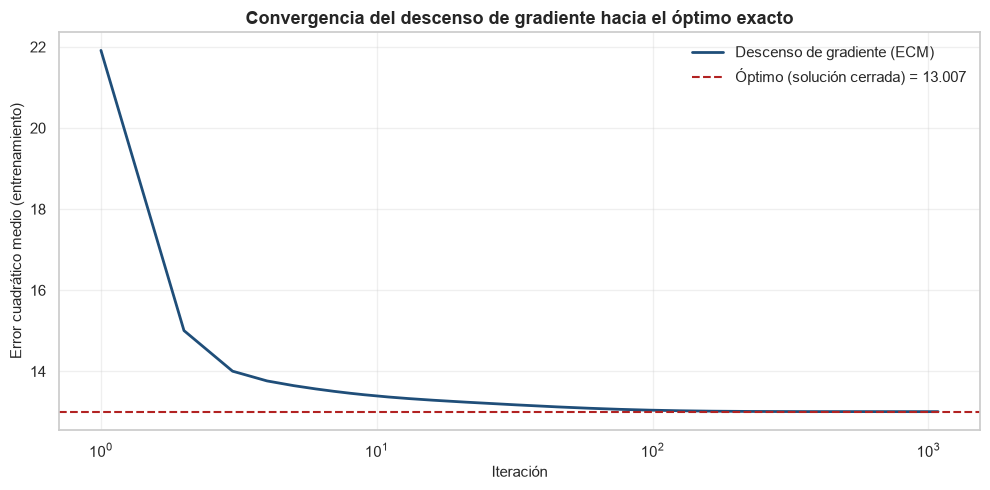

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
h = resultado.lineal_gd.historial_perdida
ax.plot(range(1, len(h) + 1), h, linewidth=2, color=config.PALETA["primario"], label="Descenso de gradiente (ECM)")
ecm_cerrada = np.mean((resultado.lineal_cerrada.predecir(X_ent) - yr_ent) ** 2)
ax.axhline(ecm_cerrada, linestyle="--", color=config.PALETA["alerta"], label=f"Óptimo (solución cerrada) = {ecm_cerrada:.3f}")
ax.set_xscale("log")
ax.set_xlabel("Iteración"); ax.set_ylabel("Error cuadrático medio (entrenamiento)")
ax.set_title("Convergencia del descenso de gradiente hacia el óptimo exacto")
ax.legend(); fig.tight_layout()
viz.guardar(fig, "f3_convergencia_gradiente")
print(f"ECM final GD: {h[-1]:.4f} | óptimo: {ecm_cerrada:.4f} | brecha relativa: {100*(h[-1]/ecm_cerrada-1):.3f} %")

**La tasa de aprendizaje decide entre converger y divergir.** Con una tasa excesiva el descenso oscila y explota; el modelo lo detecta y lanza una excepción explícita en lugar de devolver pesos infinitos (caso de excepción controlada).

In [24]:
from src.nucleo.modelos import RegresionLinealGD

ensayo = []
for tasa in (0.05, 0.2, 0.5, 0.9, 1.5):
    try:
        m = RegresionLinealGD(tasa_aprendizaje=tasa, iteraciones=600).ajustar(X_ent, yr_ent)
        dif = np.abs(m.pesos - resultado.lineal_cerrada.pesos).max()
        ensayo.append({"tasa": tasa, "estado": "converge", "iteraciones": m.iteraciones_realizadas,
                       "dif_max_vs_cerrada": round(dif, 4), "r2_prueba": round(m.evaluar(X_pru, yr_pru)["r2"], 4)})
    except RuntimeError as e:
        ensayo.append({"tasa": tasa, "estado": "DIVERGE", "iteraciones": None,
                       "dif_max_vs_cerrada": None, "r2_prueba": None})
print(pd.DataFrame(ensayo).to_string(index=False))

 tasa   estado  iteraciones  dif_max_vs_cerrada  r2_prueba
 0.05 converge        600.0              1.4155     0.0811
 0.20 converge        600.0              0.4104     0.0854
 0.50 converge        600.0              0.0706     0.0855
 0.90  DIVERGE          NaN                 NaN        NaN
 1.50  DIVERGE          NaN                 NaN        NaN


### 7.2 Desempeño de los modelos

In [25]:
desempeno = pd.DataFrame(resultado.metricas).T
print("Regresión (sobreduración en semestres) y clasificación (titulación oportuna):")
print(desempeno[["rmse", "mae", "r2", "exactitud", "precision", "sensibilidad", "f1"]].round(3).to_string())

print(f"\nExactitud de la línea base (predecir siempre la clase mayoritaria): {resultado.exactitud_base:.3f}")
print("\nEfecto del umbral de decisión en la regresión logística (conjunto de prueba):")
print(resultado.umbrales.to_string(index=False))
desempeno.round(4).to_csv(config.TABLES_DIR / "f3_desempeno_modelos.csv")
resultado.umbrales.to_csv(config.TABLES_DIR / "f3_umbrales_logistica.csv", index=False)

Regresión (sobreduración en semestres) y clasificación (titulación oportuna):
                          rmse    mae     r2  exactitud  precision  sensibilidad     f1
lineal_gd_entrenamiento  3.606  2.382  0.089        NaN        NaN           NaN    NaN
lineal_gd_prueba         3.590  2.380  0.085        NaN        NaN           NaN    NaN
lineal_cerrada_prueba    3.590  2.380  0.085        NaN        NaN           NaN    NaN
logistica_entrenamiento    NaN    NaN    NaN      0.808      0.439         0.037  0.068
logistica_prueba           NaN    NaN    NaN      0.812      0.450         0.040  0.074

Exactitud de la línea base (predecir siempre la clase mayoritaria): 0.814

Efecto del umbral de decisión en la regresión logística (conjunto de prueba):
 umbral  exactitud  precision  sensibilidad    f1
   0.50      0.812      0.450         0.040 0.074
   0.40      0.803      0.404         0.119 0.184
   0.30      0.773      0.374         0.320 0.345
   0.19      0.676      0.309         0.

### 7.3 Interpretación

- **Convergencia verificada.** Los coeficientes por descenso de gradiente
  coinciden con la solución cerrada hasta la tercera cifra decimal en casi
  todas las variables (diferencia máxima 0,012, en la categoría menos frecuente,
  Humanidades, cuyo gradiente es el más pequeño y por tanto el más lento en
  converger), y la curva de pérdida se aplana sobre el óptimo exacto. El
  algoritmo implementado a mano funciona, y el ensayo de tasas muestra el otro
  lado: con 0,9 o más diverge y el modelo lo detecta.
- **Capacidad explicativa limitada, como se anticipó en F2.** Un R² cercano a
  0,08 indica que las variables institucionales y demográficas disponibles
  explican una fracción pequeña de la variación individual de la sobreduración:
  el rezago depende sobre todo de trayectorias personales que la base no
  registra. Los coeficientes, en cambio, sí son informativos y coherentes con
  el análisis descriptivo: estudiar en una universidad suma alrededor de un
  semestre de sobreduración respecto de un CFT (categoría de referencia), ser
  mujer resta, y una mayor duración teórica o una mayor edad de ingreso restan.
- **En clasificación, la exactitud engaña.** Con un 19 % de titulación
  oportuna, predecir siempre "no oportuna" ya acierta el 81 %; la regresión
  logística con umbral 0,5 apenas supera esa línea base porque casi nunca
  predice la clase minoritaria (sensibilidad 4 %). Bajar el umbral a la
  prevalencia eleva la sensibilidad a ~60 % a costa de la precisión: la métrica
  correcta depende del uso —detectar riesgo de rezago exige sensibilidad—.
- **Proyección a F4.** Estos resultados fijan el punto de partida: variables
  adicionales (cohorte de ingreso, región, jornada), términos de interacción y
  modelos no lineales son los candidatos naturales para mejorar el ajuste.

## 8. Validación técnica

Tres niveles: la suite de `pytest` (73 pruebas: las 22 de F2 y 51 nuevas del
núcleo, que cubren casos normales, límite y excepciones), las aserciones de
coherencia con la Fase 2 dispersas en este notebook (agregación, orden,
mediana, categorías, métricas sobre objetos), y una comprobación final de
integridad del flujo completo.

In [26]:
import subprocess

# Mejora integrada desde F2: las pruebas se ejecutan con el interprete del entorno
# virtual del proyecto (no con el del kernel de Jupyter, que puede ser otro) y el
# stderr se muestra si algo falla, en lugar de dejar el error oculto.
PYTHON = RAIZ / ".venv" / "Scripts" / "python.exe"
if not PYTHON.exists():
    PYTHON = RAIZ / ".venv" / "bin" / "python"
ejecutable = str(PYTHON) if PYTHON.exists() else sys.executable
print("Intérprete:", ejecutable)

proceso = subprocess.run(
    [ejecutable, "-m", "pytest", "tests/", "-q", "--no-header"],
    cwd=RAIZ, capture_output=True, text=True,
)
print(proceso.stdout[-2500:])
if proceso.returncode != 0:
    print("--- stderr ---")
    print(proceso.stderr[-2000:])
print("Código de salida:", proceso.returncode)
assert proceso.returncode == 0, "Las pruebas automatizadas no pasaron"

Intérprete: D:\IA Development\proyecto-titulados\.venv\Scripts\python.exe


........................................................................ [ 98%]
.                                                                        [100%]
73 passed in 1.94s

Código de salida: 0


In [27]:
from src.nucleo.validacion_f3 import validador_nucleo

reporte = validador_nucleo().ejecutar({
    "df": df, "cohorte": cohorte, "arbol": arbol, "resultado": resultado,
    "X_ent": X_ent, "X_pru": X_pru,
})
print(reporte[["regla", "estado", "detalle"]].to_string(index=False))
assert (reporte["estado"] != "FALLA").all()
reporte.to_csv(config.TABLES_DIR / "f3_reporte_validacion.csv", index=False)

                  regla estado                                                                     detalle
        cohorte_y_arbol   PASA                                      cohorte=300,000, arbol.total()=300,000
      hojas_suman_total   PASA                                        suma de hojas=300,000, total=300,000
      metrica_composite   PASA                              media via arbol=2.769097, via cohorte=2.769097
tasa_oportuna_coherente   PASA objetos=18.93 %, dataset completo=18.97 % (tolerancia 1 punto por muestreo)
        convergencia_gd   PASA                                   diferencia maxima GD vs. cerrada = 0.0118
        perdida_decrece   PASA                        ECM inicial=21.9128, final=13.0065, iteraciones=1084
    matrices_modelacion   PASA                entrenamiento (160000, 16), prueba (40000, 16), sin NaN=True
       metricas_finitas   PASA                                             25 metricas, todas finitas=True
            r2_positivo   PASA       

## 9. Síntesis y proyección

**Lo construido.** Un paquete `src/nucleo` de ocho módulos con 8 clases, 5 de
ellas abstractas o base, y 51 pruebas propias. Algoritmos recursivos y
estructurados verificados contra referencias independientes; mediciones
formales con `timeit` y `tracemalloc` que confirman empíricamente las cotas
teóricas; un modelo de dominio con encapsulamiento real; cuatro patrones de
diseño con función explícita; y dos modelos implementados desde primeros
principios cuya convergencia se demuestra contra la solución exacta.

**Lo aprendido sobre eficiencia.** El orden de crecimiento decide entre
algoritmos de distinta clase (quickselect gana a ordenar); dentro de la misma
clase decide la constante, y ahí las implementaciones en C de pandas y NumPy
son imbatibles. La decisión de ingeniería es usar cada cosa donde corresponde.

**Lo que sigue en F4.** Ampliar las variables del modelo, incorporar términos
no lineales, y comunicar los resultados en el reporte final apoyándose en las
clases de esta fase —la jerarquía permite responder "dónde se concentra el
rezago" a cualquier nivel con una sola llamada—.

> **Trazabilidad:** todas las tablas de este notebook quedan en
> `reports/tables/f3_*.csv` y las figuras en `reports/figures/f3_*.png`;
> el historial de commits de la rama `fase-3/nucleo-algoritmico` registra la
> incorporación de cada módulo.